In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')

df = sns.load_dataset('titanic')
df = df.dropna(subset=['age', 'fare', 'embark_town'])

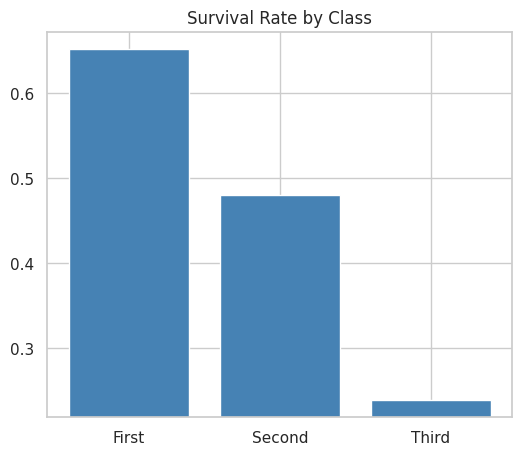

In [2]:
rate_by_class = df.groupby('class')['survived'].mean()

fig, ax = plt.subplots(figsize=(6, 5))
ax.bar(rate_by_class.index.astype(str), rate_by_class.values, color='steelblue')
ax.set_ylim(rate_by_class.min() - 0.02, rate_by_class.max() + 0.02)
ax.set_title('Survival Rate by Class')
plt.show()

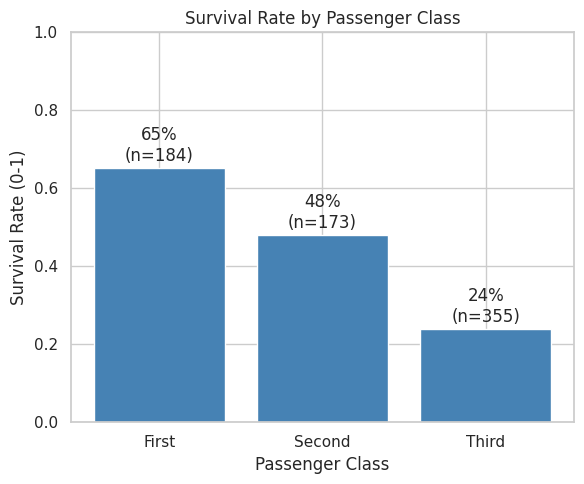

In [3]:
counts_by_class = df.groupby('class').size()

fig, ax = plt.subplots(figsize=(6, 5))
bars = ax.bar(rate_by_class.index.astype(str), rate_by_class.values, color='steelblue')
ax.set_ylim(0, 1)
ax.set_title('Survival Rate by Passenger Class')
ax.set_xlabel('Passenger Class')
ax.set_ylabel('Survival Rate (0-1)')

for bar, rate, n in zip(bars, rate_by_class.values, counts_by_class.values):
    ax.annotate(f'{rate:.0%}\n(n={n})', xy=(bar.get_x() + bar.get_width() / 2, rate),
                xytext=(0, 5), textcoords='offset points', ha='center')

plt.tight_layout()
plt.show()

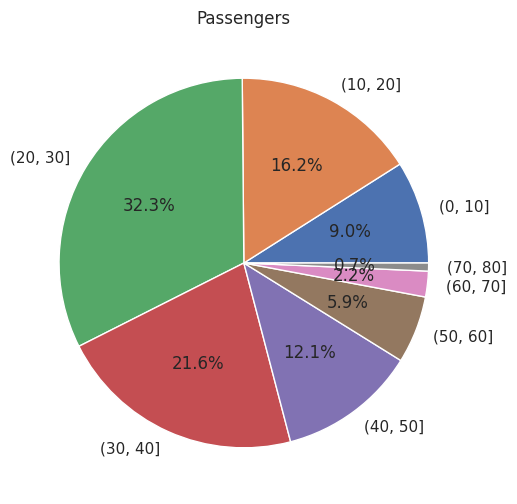

In [4]:
town_counts = df['embark_town'].value_counts()
age_bins = pd.cut(df['age'], bins=[0, 10, 20, 30, 40, 50, 60, 70, 80])
age_counts = df.groupby(age_bins).size()

fig, ax = plt.subplots(figsize=(6, 6))
ax.pie(age_counts.values, labels=[str(i) for i in age_counts.index], autopct='%1.1f%%')
ax.set_title('Passengers')
plt.show()

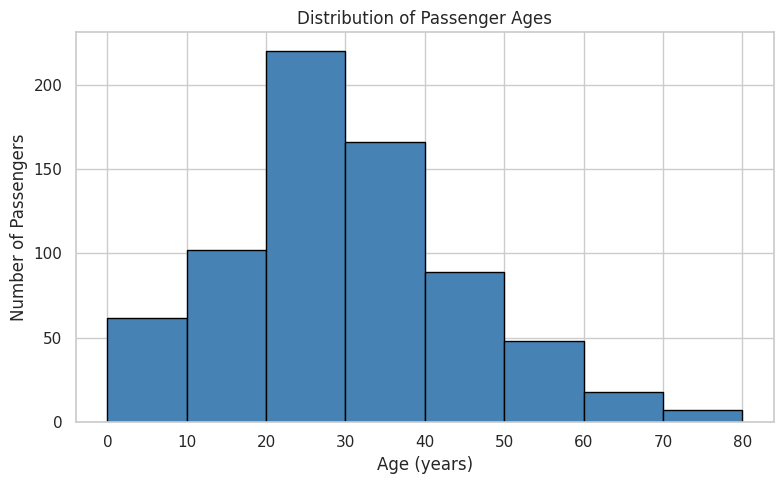

In [5]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(df['age'], bins=age_bins.cat.categories.left.tolist() + [df['age'].max()],
        edgecolor='black', color='steelblue')

ax.set_title('Distribution of Passenger Ages')
ax.set_xlabel('Age (years)')
ax.set_ylabel('Number of Passengers')
plt.tight_layout()
plt.show()